In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Your synthetic UPI data
df = pd.read_csv('data/cleaned/upi_clean.csv',
                 parse_dates=['timestamp'])

# Kaggle real fraud data (for validation/comparison)
fraud_real = pd.read_csv('data/raw/creditcard.csv')
print("UPI data:  ", df.shape)
print("Fraud data:", fraud_real.shape)
print("Real fraud rate:", round(fraud_real['Class'].mean()*100, 3), "%")

UPI data:   (8786, 17)
Fraud data: (284807, 31)
Real fraud rate: 0.173 %


In [2]:
# Z-score within each user's own transaction history
df['user_mean'] = df.groupby('user_id')['amount'].transform('mean')
df['user_std']  = df.groupby('user_id')['amount'].transform('std').fillna(1)
df['amt_zscore']= (df['amount'] - df['user_mean']) / df['user_std']
df['flag_amount']= df['amt_zscore'] > 3.0

print(f"Amount anomaly flags: {df['flag_amount'].sum()}")

Amount anomaly flags: 223


In [3]:
df['flag_night'] = (
    (df['hour'].between(0, 4)) &
    (df['amount'] > 10000)
)
print(f"Night large-amount flags: {df['flag_night'].sum()}")

Night large-amount flags: 14


In [4]:
df_sorted = df.sort_values(['user_id','timestamp'])
df_sorted['prev_ts'] = df_sorted.groupby('user_id')['timestamp'].shift(1)
df_sorted['gap_mins'] = (
    (df_sorted['timestamp'] - df_sorted['prev_ts'])
    .dt.total_seconds() / 60
)
df_sorted['flag_velocity'] = df_sorted['gap_mins'] < 10
df['flag_velocity'] = df_sorted['flag_velocity'].values
print(f"Velocity flags: {df['flag_velocity'].sum()}")

Velocity flags: 1


In [5]:
df['fraud_score'] = (
    df['flag_amount'].astype(int)   * 2 +
    df['flag_night'].astype(int)    * 2 +
    df['flag_velocity'].astype(int) * 1
)
df['fraud_risk'] = pd.cut(df['fraud_score'],
                           bins=[-1,0,2,10],
                           labels=['Clean','Moderate','High'])

print(df['fraud_risk'].value_counts())
flagged = df[df['fraud_score'] > 0]
print(f"Total flagged: {len(flagged)} ({len(flagged)/len(df)*100:.1f}% of txns)")

fraud_risk
Clean       8558
Moderate     218
High          10
Name: count, dtype: int64
Total flagged: 228 (2.6% of txns)


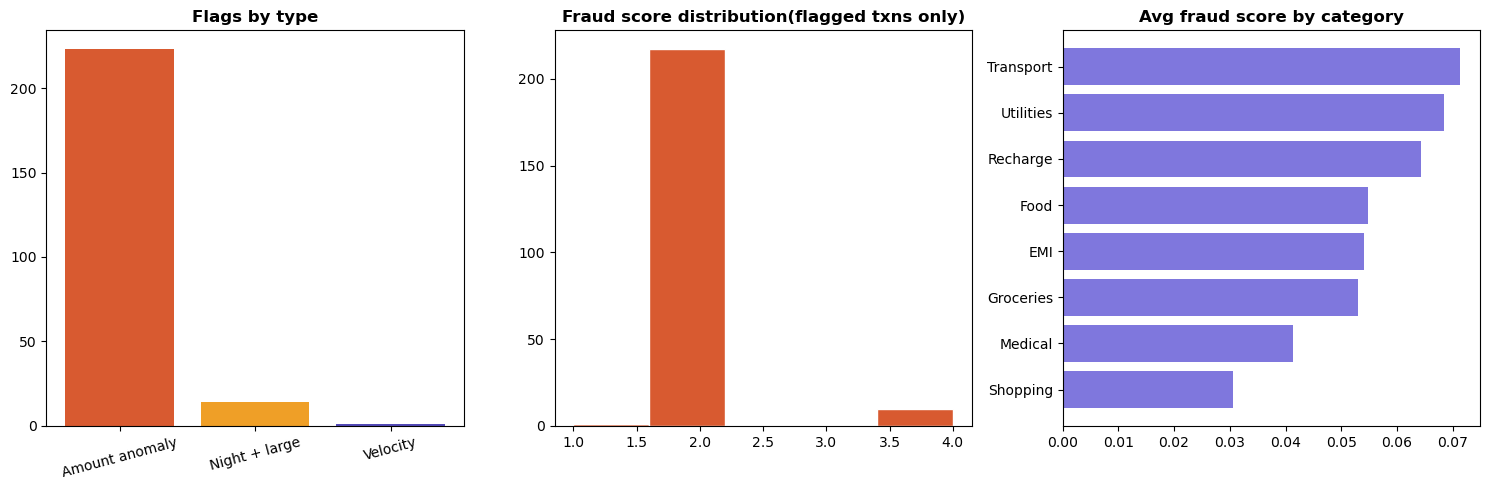

Saved: data/cleaned/upi_with_flags.csv


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Flag counts
flag_counts = {
    'Amount anomaly': df['flag_amount'].sum(),
    'Night + large':  df['flag_night'].sum(),
    'Velocity':       df['flag_velocity'].sum()
}
axes[0].bar(flag_counts.keys(), flag_counts.values(),
            color=['#D85A30','#EF9F27','#534AB7'])
axes[0].set_title('Flags by type', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# Fraud score distribution
axes[1].hist(df[df['fraud_score']>0]['fraud_score'],
             bins=5, color='#D85A30', edgecolor='white')
axes[1].set_title('Fraud score distribution(flagged txns only)', fontweight='bold')

# Fraud risk by category
cat_fraud = df.groupby('merchant_category')['fraud_score'].mean().sort_values()
axes[2].barh(cat_fraud.index, cat_fraud.values, color='#7F77DD')
axes[2].set_title('Avg fraud score by category', fontweight='bold')

plt.tight_layout()
plt.savefig('visuals/07_fraud_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

df.to_csv('data/cleaned/upi_with_flags.csv', index=False)
print("Saved: data/cleaned/upi_with_flags.csv")